## K-Means Clustering with PySpark: Hack Data

In [5]:
!powershell -command Get-Content hack_data.csv -Head 10

Session_Connection_Time,Bytes Transferred,Kali_Trace_Used,Servers_Corrupted,Pages_Corrupted,Location,WPM_Typing_Speed
8.0,391.09,1,2.96,7.0,Slovenia,72.37
20.0,720.99,0,3.04,9.0,British Virgin Islands,69.08
31.0,356.32,1,3.71,8.0,Tokelau,70.58
2.0,228.08,1,2.48,8.0,Bolivia,70.8
20.0,408.5,0,3.57,8.0,Iraq,71.28
1.0,390.69,1,2.79,9.0,Marshall Islands,71.57
18.0,342.97,1,5.1,7.0,Georgia,72.32
22.0,101.61,1,3.03,7.0,Timor-Leste,72.03
15.0,275.53,1,3.53,8.0,Palestinian Territory,70.17


In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('num_of_hackers').getOrCreate()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [7]:
df = spark.read.csv('hack_data.csv', header=True, inferSchema=True)

In [8]:
df.show(5)

+-----------------------+-----------------+---------------+-----------------+---------------+--------------------+----------------+
|Session_Connection_Time|Bytes Transferred|Kali_Trace_Used|Servers_Corrupted|Pages_Corrupted|            Location|WPM_Typing_Speed|
+-----------------------+-----------------+---------------+-----------------+---------------+--------------------+----------------+
|                    8.0|           391.09|              1|             2.96|            7.0|            Slovenia|           72.37|
|                   20.0|           720.99|              0|             3.04|            9.0|British Virgin Is...|           69.08|
|                   31.0|           356.32|              1|             3.71|            8.0|             Tokelau|           70.58|
|                    2.0|           228.08|              1|             2.48|            8.0|             Bolivia|            70.8|
|                   20.0|            408.5|              0|             3.57

In [9]:
df.describe().toPandas()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,summary,Session_Connection_Time,Bytes Transferred,Kali_Trace_Used,Servers_Corrupted,Pages_Corrupted,Location,WPM_Typing_Speed
0,count,334,334,334,334,334,334,334
1,mean,30.008982035928145,607.2452694610777,0.5119760479041916,5.258502994011977,10.838323353293413,NaN,57.342395209580864
2,stddev,14.088200614636158,286.33593163576757,0.5006065264451406,2.30190693339697,3.06352633036022,NaN,13.41106336843464
3,min,1.0,10.0,0,1.0,6.0,Afghanistan,40.0
4,max,60.0,1330.5,1,10.0,15.0,Zimbabwe,75.0


In [10]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

In [11]:
df.columns

['Session_Connection_Time',
 'Bytes Transferred',
 'Kali_Trace_Used',
 'Servers_Corrupted',
 'Pages_Corrupted',
 'Location',
 'WPM_Typing_Speed']

In [12]:
feat_cols = ['Session_Connection_Time',
 'Bytes Transferred',
 'Kali_Trace_Used',
 'Servers_Corrupted',
 'Pages_Corrupted',
 'WPM_Typing_Speed']

In [13]:
assembler = VectorAssembler(inputCols=feat_cols, outputCol='features')

In [14]:
final_df = assembler.transform(df)

In [15]:
from pyspark.ml.feature import StandardScaler

In [17]:
scaler = StandardScaler(inputCol='features', 
                        outputCol='scaled_feat',
                        withStd=True,
                        withMean=False
                       )

In [18]:
scaled_model = scaler.fit(final_df)

In [19]:
cluster_df = scaled_model.transform(final_df)

In [21]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [22]:
evaluator = ClusteringEvaluator(predictionCol='prediction',
                               featuresCol='scaled_feat',
                               metricName='silhouette',
                               distanceMeasure='squaredEuclidean')

In [24]:
silhouette_score = []
print("""
Silhouette Scores for K Means Clustering
========================================
Model\tScore\t
=====\t=====\t
""")
for k in range(2, 11):
    kmeans_algo = KMeans(featuresCol='scaled_feat', k=k)
    kmeans_fit = kmeans_algo.fit(cluster_df)
    output = kmeans_fit.transform(cluster_df)
    score = evaluator.evaluate(output)
    silhouette_score.append(score)
    print(f"K{k}\t{round(score, 2)}\t")


Silhouette Scores for K Means Clustering
Model	Score	
=====	=====	

K2	0.82	
K3	0.76	
K4	0.72	
K5	0.63	
K6	0.56	
K7	0.47	
K8	0.54	
K9	0.4	
K10	0.41	


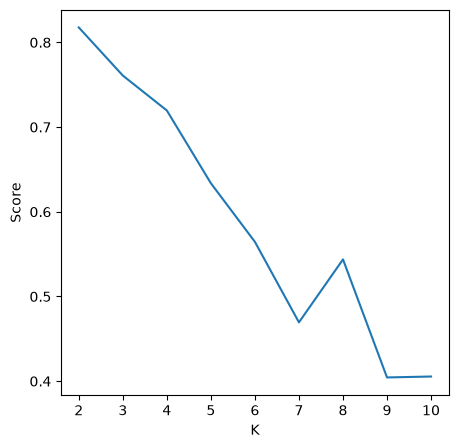

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.plot(range(2,11), silhouette_score)
ax.set_xlabel("K")
ax.set_ylabel("Score")
plt.show()